# A DNA mass conservation mechanism underpins cellular mtDNA number regulation

**Authors:** Jagir R. Hussan, Asgeir Kobro-Flatmoen, Peter Ruoff, Stig W. Omholt

## Notebook Structure
1.  **The Nucleoid:** The agent-based class defining replication rules and inheritance.
2.  **Simulation Engines:**
    * `FeedbackSimulation`: Postmitotic nucleoidstasis (Figure 1, Eq 1).
3.  **Execution & Plotting:** Generates Figure 1 in the paper.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import betabinom
import os, pickle
import dask.bag as db
from dask import delayed, compute
np.random.seed(42) #For reproducibility

# Set Global Style for Publication Quality Figures
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Arial', 'Helvetica'],
})

os.makedirs('figures', exist_ok=True)

## 1. The Nucleoid Entity

The `Nucleoid` class is the core agent in this hybrid model. 

**Key Biological Assumptions (from Manuscript):**
1.  **Intranucleoid dNTP Pool:** Each nucleoid has an associated dNTP pool, a random value [0,165690] at birth. Replication starts only when this pool exceeds the demand.
2.  **Replication Time:** mtDNA replication takes exactly 1.0 hour (`replication_time`).
3.  **Lifespan:** Nucleoids have a normally distributed lifespan $N(\mu, CV \cdot \mu)$.
4.  **Division:** Upon replication, mtDNAs are randomly shared between two daughter nucleoids.
5.  **Polymophic:** The class allows for different replication behaviours with respect to sharing of dNTP_rest and counting of dNTP_rest in the pool. This is not computationally optimal and long runs(2000 hours) take longer to complete.


In [2]:
NUMBER_MTDNA_NUCLEOIDS_WT = 5
class Nucleoid:
    mean_life_time = 100
    CV_LT = 0.2
    
    # [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 4]
    # "mtDNA replication within each nucleoid takes one hour"
    replication_time = 1.0
    
    __slots__ = ('pool_size', 'dNTP_rest', 'num_mtDNA_nuc', 'initial_mtDNA_number',
                 'number_of_replications', 'life_time', 'time_passed', 'status',
                 'rng', 'replicating', 'replication_complete', 'donot_replicate',
                 'birth_time', 'initial_pool_size', 'dead_at_time', 'mean_life_time_inst')

    def __init__(self, pool_size, dNTP_rest, num_mtDNA_nuc, rng, 
                 life_time=None, time_passed=0, number_of_replications=0, 
                 birth_time=-1, mean_life_time=None):
        
        self.pool_size = pool_size
        self.dNTP_rest = dNTP_rest
        self.num_mtDNA_nuc = num_mtDNA_nuc
        self.initial_mtDNA_number = num_mtDNA_nuc
        self.rng = rng
        
        self.mean_life_time_inst = mean_life_time if mean_life_time else self.mean_life_time
        
        # [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 4]
        # "Nucleoids were assumed to have a normal distributed lifespan N(mu, CV*mu)"
        if life_time is None:
            self.life_time = int(self.rng.normal(self.mean_life_time_inst, self.CV_LT * self.mean_life_time_inst))
        else:
            self.life_time = life_time
            
        self.time_passed = time_passed
        self.number_of_replications = number_of_replications
        self.birth_time = birth_time
        self.initial_pool_size = pool_size
        self.status = 1 # 1: Alive, 0: Dead
        self.dead_at_time = None
        self.replicating = 0.0
        self.replication_complete = 0
        self.donot_replicate = False
    
    def __getstate__(self):
        # serialization helper for dask/pickle
        return {slot: getattr(self, slot) for slot in self.__slots__}

    def __setstate__(self, state):
        # deserialization helper for dask/pickle
        for slot, value in state.items():
            setattr(self, slot, value)

    @classmethod
    def create(cls, rng, num_mtDNA, dNTP_rest=0, mean_life_time=None):
        """
        Creation logic for Figure 1 (Postmitotic).
        """
        mlt = mean_life_time if mean_life_time else cls.mean_life_time
        life_time = int(rng.normal(mlt, cls.CV_LT * mlt))
        
        pool_size = rng.integers(0,165690)
            
        return cls(pool_size, dNTP_rest, num_mtDNA, rng, life_time=life_time, mean_life_time=mlt)

    @classmethod
    def create_with_pool(cls, rng, num_mtDNA, pool_size, dNTP_rest=0, mean_life_time=None):
        """Creation with explicit pool size (Used for Figs 2 & 3)."""
        mlt = mean_life_time if mean_life_time else cls.mean_life_time
        life_time = int(rng.normal(mlt, cls.CV_LT * mlt))
        return cls(pool_size, dNTP_rest, num_mtDNA, rng, life_time=life_time, mean_life_time=mlt)

    def is_alive(self):
        return self.status == 1

    def is_replicating(self):
        """Check if currently in the 1-hour replication delay (Used in Figure 2)."""
        return self.replicating > 0.0

    def age(self, dt=1.0, current_time=0):
        if self.is_alive():
            self.life_time -= dt
            self.time_passed += dt
            if self.life_time <= 0.0:
                self.status = 0
                self.dead_at_time = current_time

    def replicate(self, mtDNA_size, nucleotide_demand, time_step=1.0, inherit_dNTPs=0, countdntpRest=False):
        """
        Replicates nucleoid if pool size is sufficient.
        
        [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 3]
        "Replication is assumed to be initiated when the size of the intranucleoid dNTP pool 
        exceeds the number of dNTPs necessary for the replication..."
        """
        self.replication_complete = 0
        total_dNTP = self.pool_size + self.dNTP_rest
        pool4division = self.pool_size
        if countdntpRest:
            pool4division = total_dNTP
        # Check conditions to Start Replication
        if self.replicating == 0.0:
            if not self.is_alive() or pool4division < nucleotide_demand:
                return None
            if self.donot_replicate:
                return None
            
            # Start timer
            self.replicating += time_step
            if self.replicating < self.replication_time:
                return None

        # Check conditions to Continue Replication
        if self.replicating > 0.0 and self.replicating < self.replication_time:
             self.replicating += time_step
             if self.replicating < self.replication_time:
                 return None
            
        # Finish Replication
        self.replicating = 0.0
        self.replication_complete = 1
        
        # [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 4]
        # "replication continues until there are not enough dNTPs"
        num_divisions = int(total_dNTP / (mtDNA_size * 2))
        total = self.num_mtDNA_nuc + num_divisions

        # [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 4]
        # "mtDNAs were randomly shared between the two daughter nucleoids"
        if total % 2 == 0:
            self.num_mtDNA_nuc = total // 2
            daughter_mtDNA = total // 2
        else:
            if self.rng.random() < 0.5:
                self.num_mtDNA_nuc = total // 2
                daughter_mtDNA = total // 2 + 1
            else:
                self.num_mtDNA_nuc = total // 2 + 1
                daughter_mtDNA = total // 2

        self.number_of_replications += 1
        leftover_dNTP = total_dNTP - num_divisions * mtDNA_size * 2
        
        # Reset parent
        self.pool_size = 0
        self.dNTP_rest = 0

        # Create daughter
        daughter_rest = 0 # Default - leftover dntp is lost
        if inherit_dNTPs == 1: #Daughter inherits leftover dNTP
            daughter_rest = leftover_dNTP
        elif inherit_dNTPs == 2: #Mother inherits leftover dNTP
            self.dNTP_rest = leftover_dNTP
        
        daughter = self.__class__(0, daughter_rest, daughter_mtDNA, self.rng, 
                                  mean_life_time=self.mean_life_time_inst)
        daughter.initial_mtDNA_number = self.initial_mtDNA_number
        
        return daughter

    def clone(self):
        new_nuc = self.__class__(self.pool_size, self.dNTP_rest, self.num_mtDNA_nuc, 
                                 self.rng, self.life_time, self.time_passed, 
                                 self.number_of_replications, self.birth_time, 
                                 self.mean_life_time_inst)
        new_nuc.status = self.status
        new_nuc.dead_at_time = self.dead_at_time
        new_nuc.initial_pool_size = self.initial_pool_size
        new_nuc.initial_mtDNA_number = self.initial_mtDNA_number
        new_nuc.donot_replicate = self.donot_replicate
        new_nuc.replicating = self.replicating
        return new_nuc

## 2. Initialization Helpers

Functions to initialize the nucleoid population based on a Beta-Binomial distribution of dNTP pool sizes.

> [Section: Nucleoid replication during the cell cycle]
> "we sampled from a discrete beta-binomial distribution X ~ BetaBin(n, alpha, beta)"

## 3. Simulation Engines

This section contains the main loops for the three different simulation scenarios.

### 1. FeedbackSimulation (Postmitotic/Figure 1)
Implements the homeostatic control Equation (1):
$$ r(t) = \frac{\kappa \cdot \theta^n}{\theta^n + N(t)^n} $$

In [3]:
class BaseSimulation:
    def __init__(self, time_span, nucleoids, mtDNA_size_WT, nucleotide_demand, 
                 rng, time_step=1.0):
        self.time_span = time_span
        self.nucs = nucleoids
        self.mtDNA_size_WT = mtDNA_size_WT
        self.nucleotide_demand = nucleotide_demand
        self.rng = rng
        self.time_step = time_step
        self.current_time = 0
        self.times = np.arange(0, time_span, time_step)
        
        self.stats = {
            'num_alive': np.zeros(len(self.times)),
            'num_dead': np.zeros(len(self.times)),
            'num_mtDNA': np.zeros(len(self.times)),
            'num_hungry': np.zeros(len(self.times)),
        }

    def _collect_stats(self, t_idx, t):
        alive = 0; dead = 0; mtDNA = 0; hungry = 0
        for n in self.nucs:
            if n.is_alive():
                alive += 1
                mtDNA += n.num_mtDNA_nuc
                if n.pool_size < self.nucleotide_demand:
                    hungry += 1
            else:
                dead += 1
        
        if t_idx < len(self.stats['num_alive']):
            self.stats['num_alive'][t_idx] = alive
            self.stats['num_dead'][t_idx] = dead
            self.stats['num_mtDNA'][t_idx] = mtDNA
            self.stats['num_hungry'][t_idx] = hungry

    def get_results(self):
        return {
            'stats': self.stats,
            'final_nucs': [n.clone() for n in self.nucs if n.is_alive()]
        }

class FeedbackSimulation(BaseSimulation):
    """Figure 1: Postmitotic feedback logic."""
    def __init__(self, time_span, nucleoids, mtDNA_size_WT, nucleotide_demand,
                 theta, n, kappa, rng, time_mutation=None, mtDNA_size_mut=None, inheritancelogic=0, countdntpRest=False):
        super().__init__(time_span, nucleoids, mtDNA_size_WT, nucleotide_demand, rng, time_step=1.0)
        self.theta = theta; self.n = n; self.kappa = kappa
        self.time_mutation = time_mutation; self.mtDNA_size_mut = mtDNA_size_mut
        self.inheritancelogic = inheritancelogic
        self.countdntpRest=countdntpRest

    def _get_current_mtDNA_size(self, t):
        if self.time_mutation and t >= self.time_mutation and self.mtDNA_size_mut:
            return self.mtDNA_size_mut
        return self.mtDNA_size_WT

    def _update_pools(self):
        """
        [Section: Conservation of mtDNA mass in a postmitotic cell, Paragraph 2]
        Implements Eq. (1): 
        rate = kappa * theta^n / (theta^n + N(t)^n)
        """
        alive_count = sum(1 for n in self.nucs if n.is_alive())
        denom = (self.theta ** self.n + alive_count ** self.n)
        rate = 0 if denom == 0 else self.kappa * (self.theta ** self.n) / denom
        for n in self.nucs:
            if n.is_alive(): n.pool_size += rate

    def run(self):
        self._collect_stats(0, 0)
        for i, t in enumerate(self.times):
            if i == 0: continue
            self.current_time = t
            current_mtDNA = self._get_current_mtDNA_size(t)
            self._update_pools()
            new_nucs = []
            for nuc in self.nucs:
                nuc.age(self.time_step, t) 
                if nuc.is_alive():
                    daughter = nuc.replicate(current_mtDNA, self.nucleotide_demand, self.time_step, inherit_dNTPs=self.inheritancelogic,countdntpRest=self.countdntpRest)
                    if daughter: new_nucs.append(daughter)
            self.nucs.extend(new_nucs)
            self.nucs = [n for n in self.nucs if n.is_alive()]
            self._collect_stats(i, t)
        return self.get_results()


## 4. Plotting Routines
Standardized plotting functions compatible with the manuscript figures.

In [4]:
os.makedirs("figures", exist_ok=True)

In [5]:
def plot_figure(results, res_pert, time_span):
    print("Plotting Figure 1...")
    fig, axes = plt.subplots(2, 1, figsize=(5.5, 7.5))
    t_pre = np.arange(250, time_span)
    
    # 1A
    p_res = res_pert[0]
    t1 = np.arange(250, 1000); t2 = np.arange(1000, 2000)
    axes[0].plot(t1, p_res['pre_alive'][250:], color='navy')
    axes[0].plot(t2[2:], p_res['remove_alive'][2:], color='firebrick', label='-70%')
    axes[0].plot(t1, p_res['pre_alive'][250:], color='darkorange')
    axes[0].plot(t2[2:], p_res['add_alive'][2:], color='seagreen', label='+70%')
    axes[0].axvline(1000, color='k', linestyle='--')
    axes[0].set_ylabel('Number of nucleoids'); axes[0].legend()
    axes[0].text(-0.1, 1.0, 'A', transform=axes[0].transAxes, weight='bold')

    bar_order = sorted(results.keys())  # or specify manually if order matters
    means = [results[k][0] for k in bar_order]
    stds  = [results[k][1] for k in bar_order]
    barix = [3,9,4,10,5,11,6,12,7,13]

    # 1. Define the groups of keys based on your description
    # Wild Type: Keys 1, 2
    wt_keys = [1, 2]

    # 25323 Group: Blue bar (14) + Red bars (barix[1::2])
    m25323_keys = barix[1::2] + [14] 

    # 9049 Group: Blue bar (8) + Green bars (barix[::2])
    m9049_keys = barix[::2] + [8] 

    # Create the new bar_order
    bar_order = wt_keys + m9049_keys + m25323_keys 

    # Extract data in the new order
    means = [results[k][0] for k in bar_order]
    stds  = [results[k][1] for k in bar_order]
    x = np.arange(len(bar_order))

    # Define colors based on the keys
    blue_bars = {2, 8, 14}
    green_bars = set(barix[::2])
    red_bars   = set(barix[1::2])
    colors = []
    for k in bar_order:
        if k in blue_bars:
            colors.append('blue')
        elif k in green_bars:
            colors.append('green')
        elif k in red_bars:
            colors.append('red')
        else:
            colors.append('olive') # WT

    # Define groups and new x-positions with gaps
    # Gap size between groups (in units of bar width usually, here simply 1.5 units)
    gap = 1.5

    # Group 1: WT (2 bars)
    x_wt = np.arange(len(wt_keys))

    # Group 2: 9049 (6 bars) -> Starts after WT + gap
    x_90 = np.arange(len(m9049_keys)) + x_wt[-1] + gap

    # Group 3: 25323 (6 bars) -> Starts after 9049 + gap
    x_25 = np.arange(len(m25323_keys)) + x_90[-1] + gap

    # Concatenate all x positions
    x_positions = np.concatenate([x_wt, x_90, x_25])

    # Extract data
    means = [results[k][0] for k in bar_order]
    stds  = [results[k][1] for k in bar_order]
    colors = [] 
    # Re-fill colors logic for the new order if needed
    for k in bar_order:
        if k in blue_bars: colors.append('blue')
        elif k in green_bars: colors.append('green')
        elif k in red_bars: colors.append('red')
        else: colors.append('olive')

    # Plot Bars
    axes[1].bar(
        x_positions,
        means,
        yerr=stds,
        capsize=5,
        alpha=0.8,
        color=colors,
        edgecolor='black',
        width=0.8  # Default width
    )

    # Set Ticks and Labels
    xlabels = [1, 2] + [3, 4, 5, 6, 7, 2] + [3, 4, 5, 6, 7, 2]
    axes[1].set_xticks(x_positions)
    axes[1].set_xticklabels(xlabels)
    axes[1].set_ylabel("Number of base pairs")
    axes[1].spines[['top','right']].set_visible(False)
    axes[1].text(-0.1, 1.0, 'B', transform=axes[1].transAxes, weight='bold')

    # Add Separation Lines and Group Labels
    line_y = -0.15
    label_y = -0.18

    groups_info = [
        (x_wt, 'WT'),
        (x_25, '25323 bp'),
        (x_90, '9049 bp'),
    ]

    for x_group, label in groups_info:
        # Calculate start and end of the group (taking bar width into account)
        # Assuming bar width is 0.8, we extend 0.4 to left and right of center
        x_start = x_group[0] - 0.4
        x_end = x_group[-1] + 0.4
        
        # Draw horizontal line
        # transform=axes[1].get_xaxis_transform() makes x=data coords, y=axis fraction
        axes[1].plot([x_start, x_end], [line_y, line_y], 
                    transform=axes[1].get_xaxis_transform(), 
                    color='black', clip_on=False, linewidth=1.5)
        
        # Add text
        center = (x_start + x_end) / 2
        axes[1].text(center, label_y, label, 
                    transform=axes[1].get_xaxis_transform(), 
                    ha='center', va='top', fontweight='bold')

    # 1. Determine the WT Reference value.
    wt_exp_mean = results[2][0] 
    wt_pred_mean = results[1][0] 

    # 2. Calculate a single fixed height for ALL text.
    # We find the tallest point in the chart (mean + std) across all bars
    all_heights = [m + s for m, s in zip(means, stds)]
    max_height = max(all_heights)
    
    # Set text position at 10% above the tallest bar to ensure clearance
    text_y_pos = max_height * 1.03

    # 3. Iterate through bars to add text
    for x_pos, key in zip(x_positions, bar_order):
        
        # Check if the key corresponds to Green, Red, or experimental Blue
        if key not in [1, 2]:
            
            curr_mean = results[key][0]
            
            # Calculate Ratio
            ratio = curr_mean / wt_pred_mean
            if key in [8,14]:
                ratio = curr_mean / wt_exp_mean
            label_txt = f"{ratio:.2f}"
            
            # Use the FIXED text_y_pos variable here
            axes[1].text(
                x_pos, 
                text_y_pos, 
                label_txt, 
                ha='center', 
                va='bottom', 
                rotation=90, 
                fontsize=10, 
                fontweight='bold',
                color='black'
            )

    # 4. Crucial: Adjust Y-axis limit so the new text fits
    # We add a little extra space above the text
    axes[1].set_ylim(top=text_y_pos * 1.15)


    # You may need to adjust the bottom margin to prevent clipping
    # plt.subplots_adjust(bottom=0.2)
    axes[0].set_xlabel('Time (hours)')
    
    fig.tight_layout(); plt.savefig(f'figures/Figure_1.pdf')


## 5. Simulation Runners

Configuration for constants and parallel execution wrappers.

In [6]:
# Global
NUM_REPLICATES = 50
MTDNA_SIZE_WT = 16569
NUMBER_MTDNA_NUCLEOID_WT = 5
CPU_N = min(NUM_REPLICATES, os.cpu_count() // 2)

# Fig 1 Constants
F1_TIME_SPAN = 2000; F1_TIME_MUTATION = 1000
F1_THETA = 3000; F1_N = 2; F1_KAPPA = 4420.0; F1_NUM_INITIAL = int(13056 / 5)

# --- Runners ---

def run_fig1_mutation(args):
    seed, mt_size_mut, time_span, t_mut, inheritancelogic,countinglogic = args
    rng = np.random.default_rng(seed)
    nucleoids = [Nucleoid.create(rng, NUMBER_MTDNA_NUCLEOIDS_WT) for _ in range(F1_NUM_INITIAL)]
    sim = FeedbackSimulation(time_span, nucleoids, MTDNA_SIZE_WT, MTDNA_SIZE_WT*2*5,
                             F1_THETA, F1_N, F1_KAPPA, rng, t_mut, mt_size_mut,
                             inheritancelogic=inheritancelogic,countdntpRest=countinglogic)
    res = sim.run()
    return {'alive': res['stats']['num_alive'], 'mtDNA': res['stats']['num_mtDNA']}


def run_fig1_perturbation(args):
    seed, time_span = args
    rng = np.random.default_rng(seed)
    nucleoids = [Nucleoid.create(rng, 5) for _ in range(F1_NUM_INITIAL)]
    sim1 = FeedbackSimulation(time_span, nucleoids, MTDNA_SIZE_WT, MTDNA_SIZE_WT*2*5,
                              F1_THETA, F1_N, F1_KAPPA, rng)
    res1 = sim1.run()
    final_nucs = res1['final_nucs']
    num_alive = res1['stats']['num_alive']
    print("Pre ",np.mean(num_alive[500:]))
    # Remove
    n_keep = int(len(final_nucs) * 0.3)
    nucs_remove = list(rng.choice(final_nucs, n_keep, replace=False))
    sim_rem = FeedbackSimulation(time_span, [n.clone() for n in nucs_remove], MTDNA_SIZE_WT, MTDNA_SIZE_WT*2*5,
                                 F1_THETA, F1_N, F1_KAPPA, rng)
    # Add
    new_nucs = [Nucleoid.create(rng, 5) for _ in range(int(len(final_nucs) * 0.7))]
    nucs_add = [n.clone() for n in final_nucs] + new_nucs
    sim_add = FeedbackSimulation(time_span, nucs_add, MTDNA_SIZE_WT, MTDNA_SIZE_WT*2*5,
                                 F1_THETA, F1_N, F1_KAPPA, rng)
    res2 = sim_rem.run()
    num_alive = res2['stats']['num_alive']
    print(f"Mean number of nucleoids for -70 {np.mean(num_alive[500:])}")    
    res3 = sim_add.run()
    num_alive = res3['stats']['num_alive']
    print(f"Mean number of nucleoids for +70 {np.mean(num_alive[500:])}")    

    return {'pre_alive': res1['stats']['num_alive'], 
            'remove_alive':res2['stats']['num_alive'], 
            'add_alive': res3['stats']['num_alive']}


## 6. Execution: Figure 1
Simulating postmitotic cells, mtDNA mutation, and recovery from perturbation.

In [ ]:
savefile = "figures/figure1.pkl"
if not os.path.exists(savefile):
  
    sizes = [25323, 9049]

    # (name, dntprest_mode, counted)
    experiments = [
        ("loss",             0, False),
        ("daughter",         1, False),
        ("mother",           2, False),
        ("daughter_counted", 1, True),
        ("mother_counted",   2, True),
    ]    
    temp_structure = {name: {} for name, _, _ in experiments}

    # Build the graph logically without flattening
    for size in sizes:
        for name, dntprest, counted in experiments:
            
            # Create the list of replicates for this specific combo
            replicate_tasks = []
            
            for i in range(NUM_REPLICATES):
                args = (i, size, F1_TIME_SPAN, F1_TIME_MUTATION, dntprest, counted)
                
                # Use delayed to schedule the function call lazily.
                # This creates a lightweight placeholder, not the result.
                task = delayed(run_fig1_mutation)(args)
                replicate_tasks.append(task)
            
            # Assign the list of tasks directly to the dictionary.
            # Dask guarantees list order is preserved upon computation.
            temp_structure[name][size] = replicate_tasks

    #  Compute everything in one pass.
    #    Dask traverses the nested dicts/lists and resolves the delayed objects.
    #    The result has the exact same structure as temp_structure, but with values.
    (final_output,) = compute(temp_structure, scheduler="processes",  num_workers=NUM_REPLICATES)

    # Extract results in the specific order required
    sim_results = [
        final_output["loss"],
        final_output["mother_counted"],
        final_output["mother"],
        final_output["daughter_counted"],
        final_output["daughter"],
    ]
    #Peturbation experiments
    args_pert = [(i, 1000) for i in range(NUM_REPLICATES)]
    res_pert = db.from_sequence(args_pert).map(run_fig1_perturbation).compute()
    # 5. Save
    with open(savefile, "wb") as ser:
        pickle.dump([sim_results,res_pert], ser)

else:
    with open(savefile,'rb') as ser:
        sim_results,res_pert = pickle.load(ser)    

Pre  2598.024
Pre  2617.864
Pre  2609.612
Pre  2613.134
Mean number of nucleoids for -70 2589.002
Pre  2588.108
Pre  2577.04
Pre  2610.562
Pre  2599.768
Pre  2576.348
Mean number of nucleoids for -70 2575.482
Mean number of nucleoids for -70 2582.706
Mean number of nucleoids for +70 2606.488
Mean number of nucleoids for -70 2596.174
Pre  2582.004
Mean number of nucleoids for -70 2616.758
Mean number of nucleoids for -70 2587.114
Mean number of nucleoids for +70 2590.946
Mean number of nucleoids for +70 2584.152
Mean number of nucleoids for -70 2608.564
Mean number of nucleoids for -70 2594.25
Mean number of nucleoids for -70 2612.184
Mean number of nucleoids for -70 2586.35
Pre  2596.126
Mean number of nucleoids for +70 2568.194
Pre  2602.252
Mean number of nucleoids for +70 2591.722
Mean number of nucleoids for +70 2584.846
Mean number of nucleoids for +70 2601.904
Mean number of nucleoids for -70 2611.444
Mean number of nucleoids for +70 2598.608
Mean number of nucleoids for -70 2577

In [8]:
def get_mass_stats(res_list, t_pre_end, t_post_start,bps):
    init = [np.mean(r['mtDNA'][250:t_pre_end]*bps) for r in res_list]
    final = [np.mean(r['mtDNA'][t_post_start:]*bps) for r in res_list]
    return np.mean(init), np.std(init), np.mean(final), np.std(final)
barix = [3,9,4,10,5,11,6,12,7,13]
results = {}
#Wild type
wt_mean, wt_std, _, _ = get_mass_stats(sim_results[0][25323], 990, 1400, 16569) #1
results[1] = [wt_mean, wt_std]
results[2] = [13056*16569,1063*16569]
results[14] = [8550*25323,779*25323]
results[8] = [23282*9049,1870*9049]

for bix,res_mut in enumerate(sim_results):
    _, _, m25_mean, m25_std = get_mass_stats(res_mut[25323], 990, 1400,25323)
    _, _, m90_mean, m90_std = get_mass_stats(res_mut[9049], 990, 1400,9049)    
    results[barix[2*bix]] = [m90_mean,m90_std]
    results[barix[2*bix+1]] = [m25_mean,m25_std]

Plotting Figure 1...


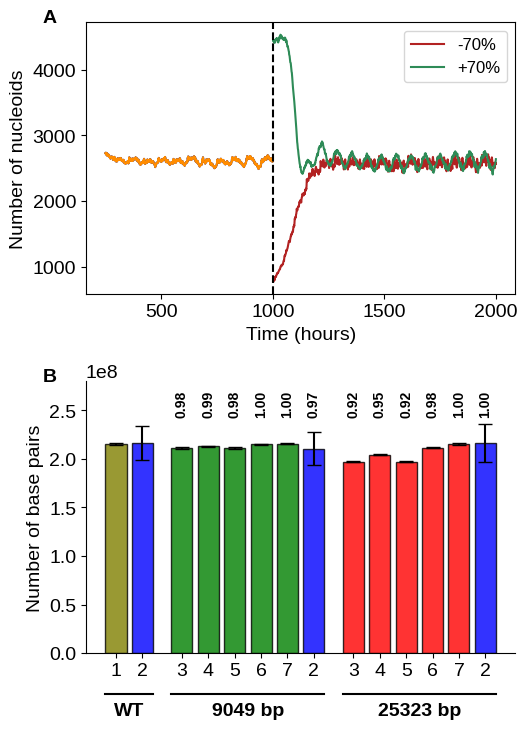

In [9]:
plot_figure(results, res_pert, F1_TIME_SPAN)